In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [13]:
class BMIClass(TypedDict):
    weight : float
    height : float
    bmi : float
    category : str

In [14]:
def calculate_bmi(state : BMIClass):
    bmi = state['weight']/(state['height'] ** 2)
    state['bmi'] = bmi
    return state

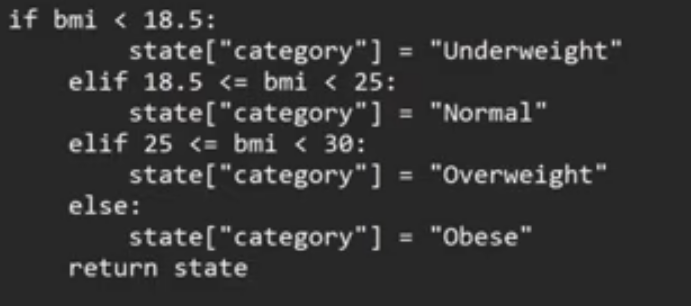

In [15]:
def label_bmi(state : BMIClass):
    
    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif bmi <= 25:
        state['category'] = 'Normal'
    elif bmi <=30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'
    
    return state


In [16]:
graph = StateGraph(BMIClass)

graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi' , 'label_bmi')
graph.add_edge('label_bmi' , END)

workflow = graph.compile()

In [17]:
initial_state = {'weight' : 55.0, 'height' : 1.72}
final_state = workflow.invoke(initial_state)
final_state

{'weight': 55.0,
 'height': 1.72,
 'bmi': 18.591130340724717,
 'category': 'Normal'}

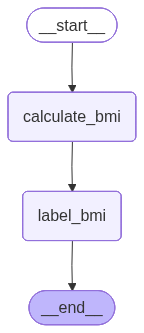

In [18]:
from IPython.display import Image
Image (workflow.get_graph().draw_mermaid_png())